[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrainardLab/PythonTeachingCode/blob/main/notebooks/key/lab_W4/False_Positives_Negatives.ipynb)

_Run this notebook in the browser — no install needed._

# COLL 0200 — Week 4 Lab 3
## Digital Companion: False Positives and Negatives

Use this notebook **only as the interactive instrument for Part I of your paper booklet**.

1. Keep your paper booklet open beside the Colab.
2. Run the setup cell once.
3. Work through Digital Sections 1, 2A, 2B, 3, 4, and 5 in order.
4. Move each decision-threshold slider and observe how the four counts and two error rates change.
5. Record every answer in the corresponding numbered question in your own booklet.

There are deliberately **no questions or response boxes in this notebook**. You are not being
asked to write Python code or edit the setup machinery.

When you finish Digital Section 5, close your laptop, and
continue entirely on paper.

If this notebook gets out of sequence, choose **Runtime → Restart session** and **Edit → Clear all outputs** and begin again from Setup.



In [1]:
#@title Setup — run this cell once
import io
import zlib

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import HTML, clear_output, display

plt.rcParams.update({
    "figure.figsize": (7.2, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})


class Test:
    """Interactive threshold model used throughout this notebook."""

    def __init__(self, config, data=None):
        self.data = None if data is None else np.asarray(data, dtype=float)
        self.title = config["title"]
        self.label_neg = config["label_neg"]
        self.label_pos = config["label_pos"]
        self.x_label = config.get("x_label", "Test Value")
        self.floor = config.get("floor")
        self.ceil = config.get("ceil")

        if self.data is None:
            self.mean_neg = config["mean_neg"]
            self.mean_pos = config["mean_pos"]
            self.std_neg = config["std_neg"]
            self.std_pos = config["std_pos"]
            self.p_pos = config["p_pos"]

        # Every case receives a stable seed derived from its title. Re-running a
        # cell therefore recreates the same displayed sample in every lab room.
        self.seed = 2026 + zlib.crc32(self.title.encode("utf-8"))

    def _single_test(self, rng):
        if rng.random() < self.p_pos:
            mean, std, actual = self.mean_pos, self.std_pos, 1
        else:
            mean, std, actual = self.mean_neg, self.std_neg, 0

        sample = rng.normal(mean, std)
        if self.floor is not None:
            sample = max(self.floor, sample)
        if self.ceil is not None:
            sample = min(self.ceil, sample)
        return [sample, actual]

    def generate(self, n):
        rng = np.random.default_rng(self.seed)
        if self.data is None:
            self.results = np.asarray([self._single_test(rng) for _ in range(n)])
        else:
            # data columns: test value, actual-positive count, actual-negative count
            total = self.data[:, 1:].sum()
            pool, weights = [], []
            for test_value, n_pos, n_neg in self.data:
                pool.extend(([test_value, 1], [test_value, 0]))
                weights.extend((n_pos / total, n_neg / total))
            chosen = rng.choice(len(pool), size=n, p=np.asarray(weights))
            self.results = np.asarray([pool[i] for i in chosen], dtype=float)
        return self.results

    def count_diagnoses(self, threshold):
        measured = self.results[:, 0]
        actual = self.results[:, 1]
        predicted_positive = measured >= threshold
        predicted_negative = ~predicted_positive

        true_pos = int(np.sum(predicted_positive & (actual == 1)))
        true_neg = int(np.sum(predicted_negative & (actual == 0)))
        false_pos = int(np.sum(predicted_positive & (actual == 0)))
        false_neg = int(np.sum(predicted_negative & (actual == 1)))
        return true_pos, true_neg, false_pos, false_neg

    # Keep the original SSS method name available.
    countDiagnoses = count_diagnoses

    @staticmethod
    def _percent(numerator, denominator):
        return 100.0 * numerator / denominator if denominator else float("nan")

    def diagnosis_summary(self, threshold):
        tp, tn, fp, fn = self.count_diagnoses(threshold)
        # Standard definitions: false-positive rate is among actual negatives;
        # false-negative rate is among actual positives.
        fpr = self._percent(fp, fp + tn)
        fnr = self._percent(fn, fn + tp)
        accuracy = self._percent(tp + tn, tp + tn + fp + fn)
        return {
            "threshold": threshold,
            "true_pos": tp,
            "true_neg": tn,
            "false_pos": fp,
            "false_neg": fn,
            "false_positive_rate": fpr,
            "false_negative_rate": fnr,
            "accuracy": accuracy,
        }

    def _plot_bounds(self, stepsize=None):
        observed_min = float(np.min(self.results[:, 0]))
        observed_max = float(np.max(self.results[:, 0]))
        if stepsize is None:
            stepsize = (observed_max - observed_min) / 100
        if stepsize <= 0:
            stepsize = 1.0
        return (
            observed_min - 5 * stepsize,
            observed_max + 5 * stepsize,
            float(stepsize),
        )

    def plot_diagnoses(self, threshold, stepsize=None):
        lower, upper, stepsize = self._plot_bounds(stepsize)
        bins = np.arange(lower, upper + stepsize, stepsize)
        fig, ax = plt.subplots()
        negative = self.results[self.results[:, 1] == 0, 0]
        positive = self.results[self.results[:, 1] == 1, 0]
        neg_counts, _, _ = ax.hist(
            negative,
            bins=bins,
            color=(31 / 255, 119 / 255, 180 / 255, 0.70),
            label=self.label_neg,
        )
        pos_counts, _, _ = ax.hist(
            positive,
            bins=bins,
            color=(255 / 255, 127 / 255, 14 / 255, 0.70),
            label=self.label_pos,
        )
        ymax = max(np.max(neg_counts, initial=0), np.max(pos_counts, initial=0), 1)
        ax.axvline(threshold, color="black", linewidth=2, label="Decision threshold")
        ax.set_xlim(lower, upper)
        ax.set_ylim(0, ymax * 1.12)
        ax.set_xlabel(self.x_label)
        ax.set_ylabel("Count")
        ax.set_title(self.title)
        ax.legend()
        fig.tight_layout()
        return fig, ax

    # Keep the original SSS method name available.
    plotDiagnoses = plot_diagnoses

    def print_diagnoses(self, threshold):
        s = self.diagnosis_summary(threshold)
        print(f"Decision threshold: {s['threshold']:.2f}")
        print(f"True positives: {s['true_pos']}")
        print(f"True negatives: {s['true_neg']}")
        print(f"False positives: {s['false_pos']}")
        print(f"False negatives: {s['false_neg']}")
        print(
            "False-positive rate (among actual negatives): "
            f"{s['false_positive_rate']:.2f}%"
        )
        print(
            "False-negative rate (among actual positives): "
            f"{s['false_negative_rate']:.2f}%"
        )
        print(f"Overall accuracy: {s['accuracy']:.2f}%")

    # Keep the original SSS method name available.
    printDiagnoses = print_diagnoses

    def plot(self, stepsize=None):
        lower, upper, stepsize = self._plot_bounds(stepsize)
        initial = (float(np.min(self.results[:, 0])) + float(np.max(self.results[:, 0]))) / 2
        integer_slider = abs(stepsize - round(stepsize)) < 1e-12 and stepsize >= 1
        slider = widgets.FloatSlider(
            value=initial,
            min=lower,
            max=upper,
            step=stepsize,
            description="Decision threshold:",
            readout_format=".0f" if integer_slider else ".2f",
            continuous_update=False,
            style={"description_width": "initial"},
            layout=widgets.Layout(width="92%"),
        )
        out = widgets.Output()

        def refresh(change=None):
            with out:
                clear_output(wait=True)
                fig, _ = self.plot_diagnoses(slider.value, stepsize=stepsize)
                display(fig)
                plt.close(fig)
                self.print_diagnoses(slider.value)

        slider.observe(refresh, names="value")
        box = widgets.VBox([slider, out])
        self._interactive_display = box
        display(box)
        refresh()
        # The cell already displays the widget explicitly. Returning the VBox
        # would make Colab auto-display the same widget a second time because
        # ``test.plot(...)`` is the cell's final expression.
        return None


ACT_GPA_CSV = r"""ACT Score,N,Above 3,Above 3 N,Above 3.5,Above 3.5 N
11,553,0.132,73,0.031,17
12,2024,0.147,298,0.05,101
13,4632,0.177,820,0.06,278
14,7645,0.188,1437,0.052,398
15,11648,0.197,2295,0.053,617
16,16731,0.223,3731,0.063,1054
17,22096,0.251,5546,0.076,1679
18,27291,0.275,7505,0.081,2211
19,31238,0.314,9809,0.099,3093
20,34160,0.36,12298,0.124,4236
21,36218,0.405,14668,0.151,5469
22,34531,0.466,16091,0.19,6561
23,32154,0.514,16527,0.234,7524
24,31135,0.576,17934,0.279,8687
25,27528,0.618,17012,0.321,8836
26,23309,0.657,15314,0.365,8508
27,19914,0.7,13940,0.416,8284
28,16208,0.725,11751,0.454,7358
29,12386,0.76,9413,0.497,6156
30,9490,0.782,7421,0.545,5172
31,6679,0.808,5397,0.587,3921
32,4528,0.833,3772,0.639,2893
33,2555,0.877,2241,0.69,1763
34,1338,0.891,1192,0.722,966
35,478,0.904,432,0.755,361
36,60,0.933,56,0.833,50"""
ACT_GPA_DATA = np.genfromtxt(io.StringIO(ACT_GPA_CSV), delimiter=",", skip_header=1)

display(HTML(
    "<div style='padding:10px 14px;border-left:5px solid #315A73;"
    "background:#F2F6F8'><b>Setup complete.</b> Continue to Part 1.</div>"
))


# Digital Section 1 — H. pylori breath test

Use this display for **Booklet Question 1**.

*Helicobacter Pylori* is a type of bacteria that can cause infections in the stomach. Symptoms of *H. pylori* include painful stomach ulcers. A common test for the infection is the urea breath test. After the patient ingests a tablet or drink containing urea enriched with the isotope carbon-13 (rather than the usual carbon-12), the test measures the proportion of carbon-13 in the carbon dioxide in the collected breath sample. If the amount of carbon-13 is in excess of the normal amount of carbon-13 in one's breath, then it suggests the presence of the bacteria in the stomach, because the bacteria have converted the ingested urea into carbon dioxide. The test result is how much excess carbon-13 is found in one's breath. For example, a test result of 5 means that there is 5 times as much carbon-13 as usual.

A study was done to find the distribution of the urea test results of subjects with or without *H. pylori* infection. Below is a histogram that shows the number of patients with a particular test result. Patients without the infection are plotted in blue; those who are infected are plotted in orange.

https://onlinelibrary.wiley.com/doi/epdf/10.1046/j.1365-2036.2003.01417.x

In [2]:
config_hpylori = {
    'title': 'H. pylori breath test',
    'mean_neg': 0.16,
    'mean_pos': 30.2,
    'std_neg': 0.36,
    'std_pos': 2.5,
    'p_pos': .549,
    'label_neg': 'No H. pylori infection',
    'label_pos': 'H. pylori infected'
}
test_hpylori = Test(config_hpylori)
test_hpylori.generate(1000)
test_hpylori.plot()

# Digital Section 2A — Pregnancy test: day 9

Use this display for **Booklet Question 2a**.

In the first days of pregnancy, the body produces a hormone called human chorionic gonadotropin (hCG). A home pregnancy kit works by detecting the presence of this hormone in the urine as an indication of pregnancy. The concentration of hCG is measured in units of milli-international units per millilitre (mIU/mL). hCG levels in a non-pregnant woman is typically less than 5 mIU/mL, and the number increases rapidly after the implantation of the embryo.

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4119102/

http://www.clinlabnavigator.com/human-chorionic-gonadotropin-pregnancy-test.html

In [3]:
config_preg_day9 = {
    'title': 'hCG Levels in Urine on 9-th Day of Pregnancy',
    'mean_neg': 0.1,
    'mean_pos': 4.04,
    'std_neg': 0.02,
    'std_pos': 1.9,
    'floor': 0,
    'p_pos': 0.8,
    'label_neg': 'Not pregnant',
    'label_pos': 'Pregnant'
}
test_preg_day9 = Test(config_preg_day9)
test_preg_day9.generate(1000)
test_preg_day9.plot()

# Digital Section 2B — Pregnancy test: day 11

Use this display for **Booklet Question 2b**. The measured quantity is still urinary hCG; compare this later-day distribution with Digital Section 2A.


In [ ]:
config_preg_day11 = {
    'title': 'hCG Levels in Urine on 11-th Day of Pregnancy',
    'mean_neg': 0.1,
    'mean_pos': 25.04,
    'std_neg': 0.02,
    'std_pos': 8.1,
    'floor': 0,
    'p_pos': 0.8,
    'label_neg': 'Not pregnant',
    'label_pos': 'Pregnant'
}
test_preg_day11 = Test(config_preg_day11)
test_preg_day11.generate(1000)
test_preg_day11.plot()

# Digital Section 3 — Smoke detector

Use this display for **Booklet Question 3**.

Smoke detectors work by measuring how much the air is dispersing light. The more smoke there is, the less light will be able to pass through the air. The quantity measured by a smoke detector is called the "optical density", which has the units of "percent per metre" (%/m). The goal of a smoke detector is to warn inhabitants of a house of a possible dangerous fire.

The following graph shows the number of times a certain value of optical density has been measured in various scenarios. The blue histogram counts those times when there is no dangerous fire (perhaps there is some greasy haze in the room from a stirfry), and the orange histogram counts those times when there is a dangerous fire (perhaps a stack of paper has been lit up by a cigarette).

https://iafss.org/publications/aofst/3/319/view/aofst_3-319.pdf

In [ ]:
config_CO_detector = {
    'title': 'Optical Density (%/m)',
    'mean_neg': 0.2,
    'mean_pos': 3,
    'std_neg': 0.1,
    'std_pos': 1.5,
    'floor': 0,
    'p_pos': 0.6,
    'label_neg': 'No Fire',
    'label_pos': 'Fire'
}
test_CO_detector = Test(config_CO_detector)
test_CO_detector.generate(1000)
test_CO_detector.plot()

# Digital Section 4 — ACT score and first-year GPA

Use this display for **Booklet Question 4**.

The binary classification of positives and negatives as well as the trade-off between false positive rate and false negative rate have important social consequences, especially when the subjects of classification are individual humans.

One example of such a classification is the admission of undergraduates to universities on the basis of standardised test performance. A good score on tests like the ACT and SAT is known to correlate strongly with a high GPA in university. As the following graph shows, the higher the ACT score, the more likely it is that a student with that ACT score will achieve a high GPA.

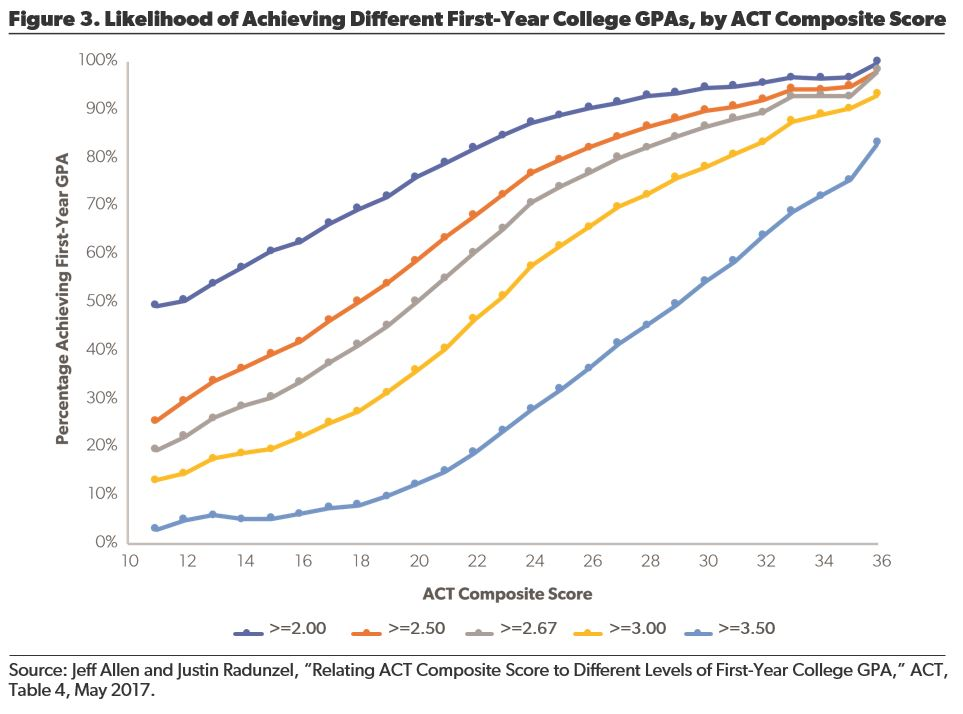!

Suppose you are a college admissions officer who is given the task of setting an ACT score cut-off, so that only students who score above this cut-off will be considered for admission at all. The college administration tells you that whatever value you choose, they would like at least 50% of the admitted students to eventually have a GPA of over 3.0 in their first year, in order to maintain the university's historically positive reputation.

https://www.act.org/content/dam/act/unsecured/documents/R1645-act-composite-to-fygpa-2017-05.pdf

In [ ]:
config = {
    'title': 'ACT Scores',
    'label_neg': 'First year GPA <3.0',
    'label_pos': 'First year GPA ≥3.0'
}
act_data = ACT_GPA_DATA.copy()
# ACT score, N, % above 3.0, N above 3.0, % above 3.5, N above 3.5
data = np.vstack((act_data[:,0], act_data[:,3], act_data[:,1]-act_data[:,3])).T
test_act = Test(config=config, data=data)
test_act.generate(10000)
test_act.plot(stepsize=1)

# Digital Section 5 — Spam filter

Use this display for **Booklet Question 5**.



We are no strangers to spam—unsolicited emails. Many email providers implement a filter that is able to recognise spam emails just from its text. We call such a problem "spam vs ham classification" (ham is not spam). The filter system usually assigns a "spam score" to each email. The higher the score, the more likely that email is spam.

On a basic level, if the email contains phrases like _collect your lotto prize_, _I am a Nigerian prince_, or _singles in your area_, some points may be added to its spam score. Likewise, an abundance of typos like _helo_, _doller_, _bizness_, or _wrold_ may also contribute to the spam score. More sophisticated filters may also look at other factors such as grammatical errors, capitalisation, hyperlinks, and formatting.

In the following histogram, we've recorded the spam/ham classification of 10,000 emails, as well as their spam scores.

In [ ]:
config_spam = {
    'title': 'Spam score',
    'mean_neg': 50,
    'mean_pos': 140,
    'std_neg': 20,
    'std_pos': 40,
    'floor': 0,
    'p_pos': 0.55,
    'label_neg': 'Ham',
    'label_pos': 'Spam'
}
test_spam = Test(config_spam)
test_spam.generate(10000)
test_spam.plot()

# Digital portion complete — close your laptop

Finish the response you are writing in **Booklet Question 5**. Close the Colab and put your laptop away.

Continue with **Part II** in the paper booklet. Computers remain closed for the rest of the lab.
